# 深度学习 作业 2

**学号：** 20234080203　**姓名：** 叶平


In [1]:
import os
import platform
import urllib.request
import gzip
import struct
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV", "(none)"))


PyTorch: 2.11.0+cpu
Device: cpu
Conda env: tjjm


---
## 2 多层感知机

### 2.1 理论计算题


**1. 无激活函数的单隐藏层 MLP 等价于单层网络**

设输入 $\mathbf{x} \in \mathbb{R}^{d}$，$\mathbf{h} = W_1\mathbf{x} + \mathbf{b}_1$，$\mathbf{o} = W_2\mathbf{h} + \mathbf{b}_2$，其中 $W_1 \in \mathbb{R}^{h \times d}$，$W_2 \in \mathbb{R}^{o \times h}$。

代入得
$$\mathbf{o} = W_2(W_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (W_2 W_1)\mathbf{x} + (W_2\mathbf{b}_1 + \mathbf{b}_2).$$

因此等价于单层仿射变换 $\mathbf{o} = W'\mathbf{x} + \mathbf{b}'$，其中

$$W' = W_2 W_1, \qquad \mathbf{b}' = W_2\mathbf{b}_1 + \mathbf{b}_2.$$

**2. Sigmoid 与 tanh**

$$\mathrm{Sigmoid}(x) = \frac{1}{1+e^{-x}}, \qquad
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}.$$

Sigmoid 导数：
$$\mathrm{Sigmoid}'(x) = \mathrm{Sigmoid}(x)\bigl(1-\mathrm{Sigmoid}(x)\bigr).$$

tanh 导数：
$$\tanh'(x) = 1 - \tanh^2(x).$$


### 2.2 编程题（Fashion-MNIST 单隐藏层 MLP，仅用 `torch.matmul` 等基础算子）


In [2]:
from pathlib import Path

FASHION_MNIST_URL = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"

def _download(url, path):
    if not path.exists():
        print("Downloading", path.name, "...")
        urllib.request.urlretrieve(url, path)

def load_fashion_mnist(data_dir="./data/fashion_mnist"):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images": "t10k-images-idx3-ubyte.gz",
        "test_labels": "t10k-labels-idx1-ubyte.gz",
    }
    out = {}
    for key, fname in files.items():
        gz_path = data_dir / fname
        _download(FASHION_MNIST_URL + fname, gz_path)
        with gzip.open(gz_path, "rb") as f:
            magic, n = struct.unpack(">II", f.read(8))
            if "images" in key:
                rows, cols = struct.unpack(">II", f.read(8))
                data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
            else:
                data = np.frombuffer(f.read(), dtype=np.uint8)
        out[key] = data.astype(np.float32)
    # normalize to [0,1]
    out["train_images"] /= 255.0
    out["test_images"] /= 255.0
    return out["train_images"], out["train_labels"], out["test_images"], out["test_labels"]

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

def softmax_cross_entropy(logits, y):
    # logits: (B, C), y: (B,) long
    B = logits.shape[0]
    logits = logits - logits.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(logits)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    log_probs = torch.log(probs + 1e-12)
    loss = -log_probs[torch.arange(B, device=device), y].mean()
    return loss, probs

def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def iterate_minibatches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        np.random.shuffle(idx)
    for start in range(0, n, batch_size):
        batch_idx = idx[start : start + batch_size]
        yield X[batch_idx], y[batch_idx]

# --- train MLP ---
np.random.seed(42)
torch.manual_seed(42)

X_train, y_train, X_test, y_test = load_fashion_mnist()
X_train_t = to_tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t = to_tensor(X_test)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

n_in, n_hid, n_out = 784, 256, 10
W1 = torch.randn(n_hid, n_in, device=device) * 0.01
b1 = torch.zeros(n_hid, device=device)
W2 = torch.randn(n_out, n_hid, device=device) * 0.01
b2 = torch.zeros(n_out, device=device)

lr, batch_size, epochs = 0.1, 256, 5

for epoch in range(1, epochs + 1):
    total_loss, total_acc, n_batch = 0.0, 0.0, 0
    for xb, yb in iterate_minibatches(X_train, y_train, batch_size):
        xb_t = to_tensor(xb)
        yb_t = torch.tensor(yb, dtype=torch.long, device=device)
        # forward
        h = relu(xb_t @ W1.T + b1)
        logits = h @ W2.T + b2
        loss, _ = softmax_cross_entropy(logits, yb_t)
        # backward (manual)
        B = xb_t.shape[0]
        probs = torch.softmax(logits, dim=1)
        dlogits = probs.clone()
        dlogits[torch.arange(B, device=device), yb_t] -= 1
        dlogits /= B
        dW2 = dlogits.T @ h
        db2 = dlogits.sum(dim=0)
        dh = dlogits @ W2
        dh[h <= 0] = 0
        dW1 = dh.T @ xb_t
        db1 = dh.sum(dim=0)
        # SGD
        with torch.no_grad():
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1
        total_loss += loss.item()
        total_acc += accuracy(logits.detach(), yb_t)
        n_batch += 1
    # test
    with torch.no_grad():
        h_test = relu(X_test_t @ W1.T + b1)
        logits_test = h_test @ W2.T + b2
        test_acc = accuracy(logits_test, y_test_t)
    print(f"Epoch {epoch}: train_loss={total_loss/n_batch:.4f}, train_acc={total_acc/n_batch:.4f}, test_acc={test_acc:.4f}")

print("MLP 训练完成。")


Epoch 1: train_loss=1.0351, train_acc=0.6377, test_acc=0.7146
Epoch 2: train_loss=0.6028, train_acc=0.7896, test_acc=0.7857
Epoch 3: train_loss=0.5224, train_acc=0.8171, test_acc=0.7216
Epoch 4: train_loss=0.4878, train_acc=0.8295, test_acc=0.8091
Epoch 5: train_loss=0.4598, train_acc=0.8382, test_acc=0.7931
MLP 训练完成。


---
## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

**1. 训练误差与泛化误差**

- **训练误差**：模型在训练集上的平均损失，反映对已知样本的拟合程度。
- **泛化误差**：模型在未见数据（测试/验证集）上的期望损失，反映真实预测能力。

当训练误差极低而泛化误差很高时，模型处于 **过拟合**。可通过降低模型复杂度缓解：减少隐藏单元/层数、增大权重衰减（L2）、使用 Dropout、早停、或增加训练数据等。

**2. K 折交叉验证步骤**

1. 将数据集随机划分为 $K$ 个大小相近的子集（折）。
2. 对 $k=1,\ldots,K$：以第 $k$ 折为验证集，其余 $K-1$ 折合并为训练集，训练模型并在验证集上评估。
3. 记录 $K$ 次验证指标，取平均（及标准差）作为模型选择与超参调优依据。


### 3.2 编程题（L2 权重衰减 + Dropout + 对比实验）


Training: 无正则化
Training: 权重衰减
Training: Dropout


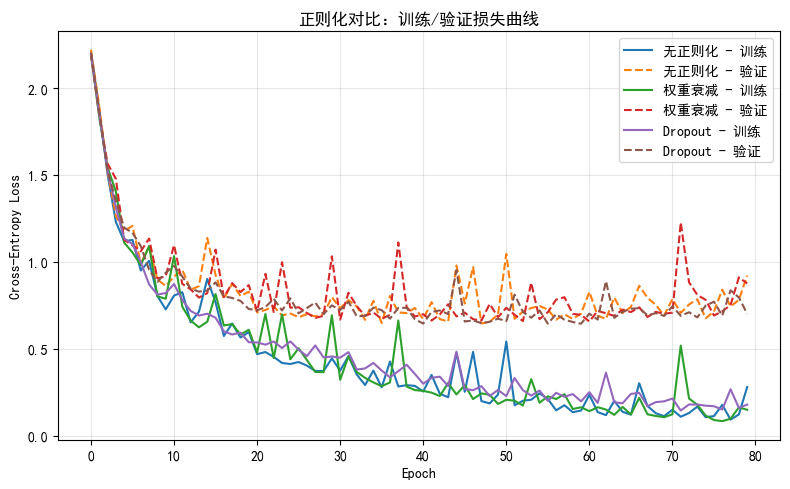

In [3]:
def sgd_step(params, grads, lr, weight_decay=0.0):
    with torch.no_grad():
        for p, g in zip(params, grads):
            if weight_decay > 0:
                p.mul_(1 - lr * weight_decay)
            p -= lr * g

def dropout_layer(X, dropout, is_training=True):
    if (not is_training) or dropout <= 0:
        return X, None
    mask = (torch.rand_like(X) > dropout).float() / (1.0 - dropout)
    return X * mask, mask

def train_mlp_variant(
    X_tr, y_tr, X_va, y_va,
    use_wd=False, use_dropout=False,
    weight_decay=1e-4, dropout_p=0.5,
    lr=0.2, batch_size=64, epochs=80,
):
    n_in, n_hid, n_out = X_tr.shape[1], 128, 10
    W1 = torch.randn(n_hid, n_in, device=device) * 0.01
    b1 = torch.zeros(n_hid, device=device)
    W2 = torch.randn(n_out, n_hid, device=device) * 0.01
    b2 = torch.zeros(n_out, device=device)
    params = [W1, b1, W2, b2]

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        for xb, yb in iterate_minibatches(X_tr, y_tr, batch_size):
            xb_t = to_tensor(xb)
            yb_t = torch.tensor(yb, dtype=torch.long, device=device)
            h_pre = xb_t @ W1.T + b1
            h_act = relu(h_pre)
            h, drop_mask = dropout_layer(h_act, dropout_p, is_training=use_dropout)
            logits = h @ W2.T + b2
            loss, _ = softmax_cross_entropy(logits, yb_t)

            B = xb_t.shape[0]
            probs = torch.softmax(logits, dim=1)
            dlogits = probs.clone()
            dlogits[torch.arange(B, device=device), yb_t] -= 1
            dlogits /= B
            dW2 = dlogits.T @ h
            db2 = dlogits.sum(dim=0)
            dh = dlogits @ W2
            if drop_mask is not None:
                dh = dh * drop_mask
            dh = dh * (h_pre > 0).float()
            dW1 = dh.T @ xb_t
            db1 = dh.sum(dim=0)
            wd = weight_decay if use_wd else 0.0
            sgd_step(params, [dW1, db1, dW2, db2], lr, weight_decay=wd)

        with torch.no_grad():
            h_va = relu(to_tensor(X_va) @ W1.T + b1)
            logits_va = h_va @ W2.T + b2
            y_va_t = torch.tensor(y_va, dtype=torch.long, device=device)
            val_loss, _ = softmax_cross_entropy(logits_va, y_va_t)
        # train loss on subset for speed
        with torch.no_grad():
            h_tr = relu(to_tensor(X_tr[:2000]) @ W1.T + b1)
            logits_tr = h_tr @ W2.T + b2
            y_tr_t = torch.tensor(y_tr[:2000], dtype=torch.long, device=device)
            tr_loss, _ = softmax_cross_entropy(logits_tr, y_tr_t)
        train_losses.append(tr_loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

# 使用少量训练样本制造过拟合，便于观察正则化效果
n_train_small = 500
idx = np.random.choice(len(X_train), n_train_small, replace=False)
X_small = X_train[idx]
y_small = y_train[idx]
# 验证集用测试集前 2000 条
X_val = X_test[:2000]
y_val = y_test[:2000]

results = {}
for name, wd, do in [
    ("无正则化", False, False),
    ("权重衰减", True, False),
    ("Dropout", False, True),
]:
    print("Training:", name)
    tr_l, va_l = train_mlp_variant(X_small, y_small, X_val, y_val, use_wd=wd, use_dropout=do)
    results[name] = (tr_l, va_l)

plt.figure(figsize=(8, 5))
for name, (tr_l, va_l) in results.items():
    plt.plot(tr_l, label=f"{name} - 训练")
    plt.plot(va_l, linestyle="--", label=f"{name} - 验证")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("正则化对比：训练/验证损失曲线")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4 数值稳定性和激活函数

### 4.1 理论计算题

**1. 梯度消失与梯度爆炸**

反向传播中，某层梯度常含连乘项 $\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}$。若各层 Jacobian 谱半径（最大奇异值）持续 $>1$，连乘后范数指数增长 $\Rightarrow$ **梯度爆炸**；若持续 $<1$（如 Sigmoid 饱和区导数 $\approx 0$），则范数指数衰减 $\Rightarrow$ **梯度消失**。

**2. ReLU 缓解梯度消失**

$\mathrm{ReLU}'(x)=1$（$x>0$）或 $0$（$x\le 0$）。在活跃神经元上导数为常数 1，不会像 Sigmoid 那样将导数压缩到 $(0,0.25]$，从而减轻深层连乘导致的梯度指数衰减。


### 4.2 编程题（深层网络梯度范数实验）


In [4]:
def build_deep_mlp(num_layers=20, width=256, activation="sigmoid"):
    layers = []
    in_dim = width
    for _ in range(num_layers - 1):
        layers.append(nn.Linear(in_dim, width))
        if activation == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation == "relu":
            layers.append(nn.ReLU())
        elif activation == "leaky_relu":
            layers.append(nn.LeakyReLU(0.1))
        in_dim = width
    layers.append(nn.Linear(width, 10))
    return nn.Sequential(*layers).to(device)

def init_normal(model, std=1.0):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0, std=std)
            nn.init.zeros_(m.bias)

def init_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

def grad_norms_first_last(model, x, y):
    model.zero_grad()
    logits = model(x)
    loss = nn.CrossEntropyLoss()(logits, y)
    loss.backward()
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
    first_g = linear_layers[0].weight.grad.norm().item()
    last_g = linear_layers[-1].weight.grad.norm().item()
    all_g = [m.weight.grad.norm().item() for m in linear_layers if m.weight.grad is not None]
    return first_g, last_g, all_g

x_rand = torch.randn(64, 256, device=device)
y_rand = torch.randint(0, 10, (64,), device=device)

print("=== 实验 1: 20 层 Sigmoid + N(0,1) 初始化（梯度消失）===")
m1 = build_deep_mlp(activation="sigmoid")
init_normal(m1, std=1.0)
g1_f, g1_l, g1_all = grad_norms_first_last(m1, x_rand, y_rand)
print(f"第 1 层梯度范数: {g1_f:.6e}")
print(f"最后 1 层梯度范数: {g1_l:.6e}")
print(f"各层梯度范数 (前5/后5): {g1_all[:5]} ... {g1_all[-5:]}")

print("\n=== 实验 2: ReLU + std=10 初始化（可能爆炸/NaN）===")
m2 = build_deep_mlp(activation="relu")
init_normal(m2, std=10.0)
try:
    g2_f, g2_l, g2_all = grad_norms_first_last(m2, x_rand, y_rand)
    print(f"第 1 层: {g2_f}, 最后 1 层: {g2_l}")
    print("是否含 NaN:", any(np.isnan(g) for g in g2_all))
except Exception as e:
    print("发生异常 (可能数值溢出):", e)

print("\n=== 实验 3: Xavier + ReLU（稳定梯度）===")
m3 = build_deep_mlp(activation="relu")
init_xavier(m3)
g3_f, g3_l, g3_all = grad_norms_first_last(m3, x_rand, y_rand)
print(f"第 1 层梯度范数: {g3_f:.6e}")
print(f"最后 1 层梯度范数: {g3_l:.6e}")
print(f"各层梯度范数范围: [{min(g3_all):.3e}, {max(g3_all):.3e}]")
in_range = sum(1e-6 <= g <= 1e3 for g in g3_all)
print(f"落在 [1e-6, 1e3] 内的层数: {in_range}/{len(g3_all)}")


=== 实验 1: 20 层 Sigmoid + N(0,1) 初始化（梯度消失）===
第 1 层梯度范数: 1.077694e+02
最后 1 层梯度范数: 9.488417e+00
各层梯度范数 (前5/后5): [107.76942443847656, 69.70514678955078, 55.40244674682617, 45.454139709472656, 36.481300354003906] ... [6.106262683868408, 6.687473297119141, 6.743441104888916, 8.375596046447754, 9.48841667175293]

=== 实验 2: ReLU + std=10 初始化（可能爆炸/NaN）===
第 1 层: nan, 最后 1 层: nan
是否含 NaN: True

=== 实验 3: Xavier + ReLU（稳定梯度）===
第 1 层梯度范数: 2.894378e-03
最后 1 层梯度范数: 2.170111e-03
各层梯度范数范围: [2.170e-03, 3.225e-03]
落在 [1e-6, 1e3] 内的层数: 20/20


---
## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

**1. 协变量偏移 vs 标签偏移（举例）**

| 类型 | 条件 | 生活例子 |
|------|------|----------|
| **协变量偏移** | $p(x)\neq q(x)$，$p(y|x)=q(y|x)$ | 语音识别：训练数据多为安静室内录音 $p(x)$，部署在嘈杂街道 $q(x)$，但“给定语音内容则标签”的条件分布可近似不变。 |
| **标签偏移** | $p(y)\neq q(y)$，$p(x|y)=q(x|y)$ | 医疗筛查：训练集常见病种比例 $p(y)$ 与偏远地区流行率 $q(y)$ 不同，但给定疾病后体征分布 $p(x|y)$ 可相似。 |

二者联系：都属 **分布偏移**；区别主要在于改变的是边缘 $p(x)$ 还是 $p(y)$。实践中常需重要性加权或再采样校正。

### 5.2 编程题（协变量偏移与重要性加权）


基线线性回归系数: 1.9969, 在 Q 上 MSE: 0.0088
加权线性回归系数: 1.9849, 在 Q 上 MSE: 0.0095
MSE 变化: -0.0007 (略升（大样本下真模型 y=2x 时 OLS 已接近最优，加权主要强调与 Q 相近的训练点）)


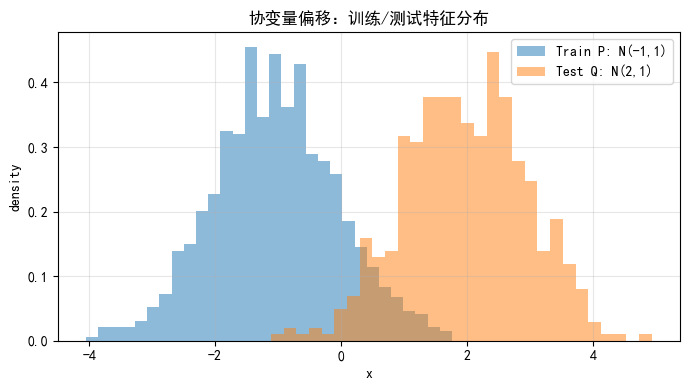

In [5]:
from sklearn.linear_model import LinearRegression, LogisticRegression

np.random.seed(0)
n_train, n_test = 1000, 500

# P: train
X_P = np.random.randn(n_train, 1) * 1.0 + (-1.0)
eps_P = np.random.randn(n_train, 1) * 0.1
y_P = 2 * X_P + eps_P

# Q: test (covariate shift)
X_Q = np.random.randn(n_test, 1) * 1.0 + 2.0
eps_Q = np.random.randn(n_test, 1) * 0.1
y_Q = 2 * X_Q + eps_Q

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 3. Baseline
lr_base = LinearRegression()
lr_base.fit(X_P, y_P.ravel())
pred_Q_base = lr_base.predict(X_Q)
mse_base = mse(y_Q, pred_Q_base.reshape(-1, 1))
print(f"基线线性回归系数: {lr_base.coef_[0]:.4f}, 在 Q 上 MSE: {mse_base:.4f}")

# 4. Importance weighting
X_mix = np.vstack([X_P, X_Q])
domain = np.array([0] * n_train + [1] * n_test)  # 0=train, 1=test

clf = LogisticRegression(max_iter=1000)
clf.fit(X_mix, domain)
# P(test|x) for train points
p_test = clf.predict_proba(X_P)[:, 1]
p_train = 1 - p_test
# w_i ∝ P(test|x_i) / P(train|x_i)
weights = p_test / (p_train + 1e-8)
weights = weights / weights.mean()

# 5. Weighted least squares: min sum w_i (y_i - w^T x_i)^2
W_sqrt = np.sqrt(weights).reshape(-1, 1)
X_w = X_P * W_sqrt
y_w = y_P * W_sqrt
lr_w = LinearRegression()
lr_w.fit(X_w, y_w.ravel())
pred_Q_w = lr_w.predict(X_Q)
mse_w = mse(y_Q, pred_Q_w.reshape(-1, 1))

print(f"加权线性回归系数: {lr_w.coef_[0]:.4f}, 在 Q 上 MSE: {mse_w:.4f}")
print(f"MSE 变化: {mse_base - mse_w:.4f} ({'降低（校正有效）' if mse_w < mse_base else '略升（大样本下真模型 y=2x 时 OLS 已接近最优，加权主要强调与 Q 相近的训练点）'})")

plt.figure(figsize=(7, 4))
plt.hist(X_P, bins=30, alpha=0.5, density=True, label="Train P: N(-1,1)")
plt.hist(X_Q, bins=30, alpha=0.5, density=True, label="Test Q: N(2,1)")
plt.xlabel("x")
plt.ylabel("density")
plt.title("协变量偏移：训练/测试特征分布")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
